In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import cm
import time
import pandas as pd
import random
import copy

In [2]:
def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    np.random.seed(seed)
# 设置随机数种子
setup_seed(123456)

In [3]:
# In[2]:
# 定义网络
class Net(nn.Module):
    def __init__(self, n_input, n_output, n_layer, n_nodes):
        # 调用初始化和定义层数
        super(Net, self).__init__()
        self.n_layer = n_layer
       
        # 存储归一化参数
        self.A_bar = A_bar
        self.B_bar = B_bar
        self.miuA_bar = miuA_bar
        self.miuB_bar = miuB_bar
        self.miu0_bar=miu0_bar
        
        # 创建可训练参数 m
        self.beta = nn.Parameter(torch.tensor(1.0, dtype=torch.float32))  # 初始猜测
    
    # 创建输入层Input(给输入数量和神经元节点数量n_input, n_nodes)，Xavier 初始化方法对权重进行初始化，使用正态分布随机初始化偏置
        self.Input = nn.Linear(n_input, n_nodes)
        nn.init.xavier_uniform_(self.Input.weight)
        nn.init.normal_(self.Input.bias)
        # 创建输出层(给神经元节点数量和输出数量)，并对权重和偏置同样进行初始化
        
        self.Output = nn.Linear(n_nodes, n_output)
        nn.init.xavier_uniform_(self.Output.weight)
        nn.init.normal_(self.Output.bias)
        # 创建隐藏层，n_layer个隐藏层进行循环，输入前后隐藏层节点数量，都是线性层，第二个循环则对权重偏置进行初始化
        self.Hidden = nn.ModuleList() # hidden layer list
        for i in range(n_layer):
            self.Hidden.append(nn.Linear(n_nodes, n_nodes))
        for layer in self.Hidden:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.normal_(layer.bias)


    # 定义向前传播过程
    def forward(self, x):
        y = torch.tanh(self.Input(x)) # tanh activation function
        for layer in self.Hidden:
            y = torch.tanh(layer(y))
        y = self.Output(y)
        return y
    
    
    # 定义miu_function作为类方法
    def miu_func(self, R_bar):
        # 添加约束确保n在合理范围内
        beta = torch.clamp(self.beta, min=0.1, max=10.0)
        miu_bar= self.miu0_bar*(1+(self.miuB_bar/self.miuA_bar-1)*(R_bar**beta-self.A_bar**beta)/(self.B_bar**beta-self.A_bar**beta))    
        return miu_bar

In [4]:
def derivativs(R, Net):
    r= Net(R)[:,0].view(-1,1)
    P_r= Net(R)[:,1].view(-1,1)
    return r, P_r

In [5]:
delta=0        
miu0=0.1802e6  ####pa
miuA=0.1802e6  ####pa
miuB=0.3166e6  ####pa
A=1                ####m
B=2                ####m
Pa=-0.1e6   ####pa
Pb=0e6

In [6]:
#无量纲
L = A  # 长度无量纲

P=miu0  # 压力无量纲


# 归一化参数
A_bar = A / L
B_bar = B / L
miu0_bar = miu0 /miu0
miuA_bar = miuA /miu0
miuB_bar = miuB /miu0


Pa_bar = Pa / P
Pb_bar = Pb / P
true_beta=1.5

In [7]:
data = pd.read_csv('COMSOL_NH_GeL_double_zhu.csv')
R_bar = data.iloc[:, 0:1].to_numpy()
sigmar = data.iloc[:, 1:4].to_numpy()
sigmatheta = data.iloc[:, 4:7].to_numpy()
sigmaz = data.iloc[:, 7:10].to_numpy()
lamdatheta = data.iloc[:, 10:13].to_numpy()

In [8]:
# 获取COMSOL数据
COMSOL_R = R_bar.flatten()
COMSOL_sigma_r = sigmar[:,2:3]
COMSOL_sigma_theta = sigmatheta[:,2:3]
COMSOL_sigma_z = sigmaz[:, 2:3]
COMSOL_lamdatheta = lamdatheta[:,2:3]

In [9]:

# 数据点总数
N = len(COMSOL_R)

# 随机选择 3 个不重复的索引
# indices = np.random.choice(N, size=3, replace=False)

indices_all = np.random.permutation(len(COMSOL_R))

indices = indices_all[:3]

# 根据索引取出对应数据
R_sample = COMSOL_R[indices]
sigma_r_sample = COMSOL_sigma_r[indices]
sigma_theta_sample = COMSOL_sigma_theta[indices]
sigma_z_sample = COMSOL_sigma_z[indices]
lamdatheta_sample = COMSOL_lamdatheta[indices]


In [10]:
# 转换为张量
COMSOL_R_tensor = torch.tensor(R_sample, dtype=torch.float32, requires_grad=True).view(-1, 1)
COMSOL_lamdatheta_tensor = torch.tensor(lamdatheta_sample, dtype=torch.float32, requires_grad=True).view(-1, 1)

In [11]:
print(COMSOL_R_tensor,COMSOL_lamdatheta_tensor)

tensor([[1.8900],
        [1.3300],
        [1.7100]], grad_fn=<ViewBackward0>) tensor([[1.1674],
        [1.3162],
        [1.2013]], grad_fn=<ViewBackward0>)


In [12]:
def derivativs2(R_bar,  Net_r):
    
    r_bar, P_r_bar = derivativs(R_bar, Net_r)

    miu_bar = Net_r.miu_func(R_bar).view(-1,1)
    
    
    I1=(r_bar/R_bar)**(-2*delta-2)+(r_bar/R_bar)**2+(r_bar/R_bar)**(2*delta)
    I2=(r_bar/R_bar)**(-2*delta)*(r_bar/R_bar)**(-2)+(r_bar/R_bar)**(2*delta+2)
    
        
    W_bar=miu_bar/2*(I1-3)
    W1_bar=miu_bar/2
    W2_bar=0
    
    
    dr_R1=torch.autograd.grad(r_bar, R_bar, torch.ones_like(r_bar), retain_graph=True, create_graph=True, allow_unused=True)
    
    dr_R = dr_R1[0]
    
    J = dr_R*(r_bar/R_bar)**(delta+1)
    
    sigma_r_bar=-P_r_bar+2*W1_bar*dr_R**2+2*W2_bar*((r_bar/R_bar)**2*dr_R**2+(r_bar/R_bar)**(2*delta)*dr_R**2)
    
       
    dsigma_r_R1=torch.autograd.grad(sigma_r_bar, R_bar, torch.ones_like(sigma_r_bar), retain_graph=True, create_graph=True, allow_unused=True)
    
    dsigma_r_R = dsigma_r_R1[0]
    
    dsigma_r_r=dsigma_r_R/(dr_R)
    
           
    
    sigma_theta_bar = -P_r_bar+2*W1_bar*(r_bar/R_bar)**2+2*W2_bar*(dr_R**2*(r_bar/R_bar)**2+(r_bar/R_bar)**(2*delta+2))

#     sigma_z_bar = -P_r_bar+2*W1_bar*(r_bar/R_bar)**(2*delta)+2*W2_bar*(dr_R**2*(r_bar/R_bar)**(2*delta)+(r_bar/R_bar)**(2*delta+2)) 
    
    sigma_z_bar = -P_r_bar+2*W1_bar
    
    return miu_bar,sigma_r_bar, sigma_theta_bar,sigma_z_bar,dsigma_r_r
    

In [13]:
def PDE(R_bar, Net_r):
    
    r_bar, P_r_bar = derivativs(R_bar, Net_r)
    
    miu_bar = Net_r.miu_func(R_bar).view(-1,1)
    
    miu_bar,sigma_r_bar, sigma_theta_bar, _, dsigma_r_r = derivativs2(R_bar,  Net_r)
        
    governing_equation_1 = dsigma_r_r+ (delta+1)*(sigma_r_bar - sigma_theta_bar) / r_bar

    return torch.mean(governing_equation_1 ** 2)

In [14]:
def J(R_bar, Net_r):
    
    r_bar, P_r_bar = derivativs(R_bar, Net_r)
    
    miu_bar = Net_r.miu_func(R_bar).view(-1,1)
    
    miu_bar,sigma_r_bar, sigma_theta_bar, _, dsigma_r_r = derivativs2(R_bar,  Net_r)
    
    dr_R1 = torch.autograd.grad(r_bar, R_bar, torch.ones_like(r_bar), retain_graph=True, create_graph=True, allow_unused=True)
    
    dr_R = dr_R1[0]

    J = dr_R*(r_bar/R_bar)**(delta+1)

    return torch.mean((J-1) ** 2)

In [15]:
def BD1(R_bar, Net_r):
       
    r_bar, P_r_bar = derivativs(R_bar, Net_r)
    
    miu_bar = Net_r.miu_func(R_bar).view(-1,1)
    
    miu_bar,sigma_r_bar, _, _, _ = derivativs2(R_bar,  Net_r)
    
    return torch.mean((sigma_r_bar-Pa_bar) ** 2)

In [16]:
def BD2(R_bar, Net_r):
       
    r_bar, P_r_bar = derivativs(R_bar, Net_r)
    miu_bar = Net_r.miu_func(R_bar).view(-1,1)
    
    miu_bar,sigma_r_bar, _, _, _ = derivativs2(R_bar,  Net_r)
    
    return torch.mean((sigma_r_bar-Pb_bar) ** 2)

In [17]:
def lamdathetaL(R_bar, Net_r):
    
    r_bar, P_r_bar = derivativs(R_bar, Net_r)
    miu_bar = Net_r.miu_func(R_bar).view(-1,1)
    
    
    miu_bar,sigma_r_bar, sigma_theta_bar, _, dsigma_r_r = derivativs2(R_bar,  Net_r)
    
    lamdatheta_bar=r_bar/R_bar
   
    return torch.mean((lamdatheta_bar  - COMSOL_lamdatheta_tensor)** 2)

In [18]:
def train_data(Nint):

    R_int_bar =np.linspace(A_bar, B_bar, Nint).reshape([Nint, 1])
    R_b1_bar = A_bar*np.ones((1,1))
    R_b2_bar = B_bar*np.ones((1,1))
    R_int_bar = torch.tensor(R_int_bar, dtype=torch.float32, requires_grad=True)
    R_b1_bar = torch.tensor(R_b1_bar, dtype=torch.float32, requires_grad=True)
    R_b2_bar = torch.tensor(R_b2_bar, dtype=torch.float32, requires_grad=True)

    return R_int_bar, R_b1_bar, R_b2_bar

In [19]:
Nint =2001

R_int_bar, R_b1_bar, R_b2_bar = train_data(Nint)

Net_r = Net(1, 2, 5, 10)


In [20]:
start_time = time.time()
nepoches = 155000
learning_rate = 1e-3
optimizer_adam = torch.optim.Adam(Net_r.parameters(), lr=learning_rate)

best_beta = None
best_loss = float('inf')
best_state = None
no_improvement_counter = 0
patience = 2000

# 记录列表
training_loss = []
loss_history = []
beta_history = []
loss_PDE_history = []
loss_J_history = []
loss_BD1_history = []
loss_BD2_history = []
loss_lamdatheta_history = []
epochs_list = []
beta_list = []

# LBFGS优化器占位
optimizer_lbfgs = None

def compute_losses():
    """计算各项损失并返回总损失和各项损失的值（用于记录）"""
    loss_PDE = PDE(R_int_bar, Net_r)
    loss_J = J(R_int_bar, Net_r)
    loss_BD1 = BD1(R_b1_bar, Net_r)
    loss_BD2 = BD2(R_b2_bar, Net_r)
    loss_lamdatheta = lamdathetaL(COMSOL_R_tensor, Net_r)

    total_loss = (
        loss_PDE
        + 10*loss_J
        + loss_BD1
        + loss_BD2
        + 100*loss_lamdatheta
    )

    return total_loss, loss_PDE, loss_J, loss_BD1, loss_BD2, loss_lamdatheta


for epoch in range(nepoches):

    # 切换优化器
    if epoch == 150000:

        optimizer_lbfgs = torch.optim.LBFGS(
            Net_r.parameters(),
            lr=1,
            max_iter=30,
            history_size=50,
            line_search_fn='strong_wolfe',
            max_eval=50,
            tolerance_grad=1e-8,
            tolerance_change=1e-10
        )

        # LBFGS阶段重新开始统计提前停止次数
        no_improvement_counter = 0

    # 优化步骤
    if epoch < 150000:

        # Adam
        optimizer_adam.zero_grad()

        total_loss, loss_PDE, loss_J, loss_BD1, \
        loss_BD2, loss_lamdatheta = compute_losses()

        total_loss.backward()

        optimizer_adam.step()

    else:

        # LBFGS - 定义闭包并执行一步优化
        def closure():

            optimizer_lbfgs.zero_grad()

            total_loss, loss_PDE, loss_J, loss_BD1, \
            loss_BD2, loss_lamdatheta = compute_losses()

            total_loss.backward()

            return total_loss

        optimizer_lbfgs.step(closure)


    # 更新参数后重新计算损失


    total_loss, loss_PDE, loss_J, loss_BD1, \
    loss_BD2, loss_lamdatheta = compute_losses()



    # 记录损失


    total_loss_val = total_loss.detach().item()

    training_loss.append(total_loss_val)
    loss_history.append(total_loss_val)

    loss_PDE_history.append(loss_PDE.detach().item())
    loss_J_history.append(loss_J.detach().item())
    loss_BD1_history.append(loss_BD1.detach().item())
    loss_BD2_history.append(loss_BD2.detach().item())
    loss_lamdatheta_history.append(loss_lamdatheta.detach().item())



    # 记录参数


    current_beta = Net_r.beta.detach().item()

    beta_history.append(current_beta)

    epochs_list.append(epoch+1)
    beta_list.append(current_beta)


    # 保存最优参数和最优网络


    if total_loss_val < best_loss:

        best_loss = total_loss_val

        best_beta = current_beta

        best_state = copy.deepcopy(Net_r.state_dict())

        no_improvement_counter = 0

    else:

        no_improvement_counter += 1



    # 提前停止检查


    if epoch >= 150000 and no_improvement_counter >= patience:

        print(
            f"Early stopping at epoch {epoch+1}, "
            f"no improvement for {patience} epochs, "
            f"best beta: {best_beta:.4f}"
        )

        break



    # 打印


    if (epoch+1) % 10 == 0:

        if epoch < 150000:

            print(
                f'epoch:{epoch+1}:  '
                f'beta:{current_beta:.6f}, '
                f'total loss:{total_loss_val:.2e}, '
                f'PDE:{loss_PDE_history[-1]:.2e}, '
                f'J:{loss_J_history[-1]:.2e}, '
                f'BD1:{loss_BD1_history[-1]:.2e}, '
                f'BD2:{loss_BD2_history[-1]:.2e}, '
                f'lamdatheta:{loss_lamdatheta_history[-1]:.2e}'
            )

        else:

            print(
                f'epoch:{epoch+1}:  '
                f'beta:{current_beta:.6f}, '
                f'total loss:{total_loss_val:.2e}, '
                f'PDE:{loss_PDE_history[-1]:.2e}, '
                f'J:{loss_J_history[-1]:.2e}, '
                f'BD1:{loss_BD1_history[-1]:.2e}, '
                f'BD2:{loss_BD2_history[-1]:.2e}, '
                f'lamdatheta:{loss_lamdatheta_history[-1]:.2e} [LBFGS]'
            )



# 恢复最优网络


if best_state is not None:

    Net_r.load_state_dict(best_state)

    best_beta = Net_r.beta.detach().item()


# 最终结果


elapsed_time = time.time() - start_time

print(f"Total training time: {elapsed_time:.2f} seconds")

print(f"\nFinal results:")

print(f"Identified beta: {best_beta:.6f}")

print(f"True beta: {true_beta}")

print(f"Relative error: "f"{abs(best_beta - true_beta) / abs(true_beta) * 100:.2f}%")

epoch:10:  beta:0.994835, total loss:3.32e+01, PDE:3.10e-01, J:9.37e-01, BD1:3.90e+00, BD2:2.06e+00, lamdatheta:1.75e-01
epoch:20:  beta:1.001810, total loss:2.40e+01, PDE:5.89e-01, J:9.19e-01, BD1:3.60e+00, BD2:1.83e+00, lamdatheta:8.82e-02
epoch:30:  beta:1.012901, total loss:1.87e+01, PDE:7.46e-01, J:9.10e-01, BD1:3.27e+00, BD2:1.60e+00, lamdatheta:3.98e-02
epoch:40:  beta:1.025053, total loss:1.61e+01, PDE:7.54e-01, J:9.03e-01, BD1:2.93e+00, BD2:1.38e+00, lamdatheta:1.99e-02
epoch:50:  beta:1.037163, total loss:1.49e+01, PDE:6.99e-01, J:8.94e-01, BD1:2.61e+00, BD2:1.17e+00, lamdatheta:1.44e-02
epoch:60:  beta:1.048753, total loss:1.40e+01, PDE:6.30e-01, J:8.78e-01, BD1:2.30e+00, BD2:9.79e-01, lamdatheta:1.34e-02
epoch:70:  beta:1.059780, total loss:1.33e+01, PDE:5.67e-01, J:8.56e-01, BD1:2.01e+00, BD2:8.04e-01, lamdatheta:1.31e-02
epoch:80:  beta:1.070332, total loss:1.24e+01, PDE:5.11e-01, J:8.27e-01, BD1:1.74e+00, BD2:6.50e-01, lamdatheta:1.27e-02
epoch:90:  beta:1.080464, total 

epoch:690:  beta:1.415085, total loss:2.73e-02, PDE:7.17e-03, J:1.88e-03, BD1:2.66e-04, BD2:6.04e-04, lamdatheta:4.78e-06
epoch:700:  beta:1.415588, total loss:2.63e-02, PDE:6.88e-03, J:1.82e-03, BD1:2.58e-04, BD2:5.69e-04, lamdatheta:4.49e-06
epoch:710:  beta:1.416055, total loss:2.54e-02, PDE:6.62e-03, J:1.76e-03, BD1:2.50e-04, BD2:5.36e-04, lamdatheta:4.23e-06
epoch:720:  beta:1.416484, total loss:2.45e-02, PDE:6.36e-03, J:1.70e-03, BD1:2.41e-04, BD2:5.06e-04, lamdatheta:3.98e-06
epoch:730:  beta:1.416878, total loss:2.37e-02, PDE:6.12e-03, J:1.65e-03, BD1:2.31e-04, BD2:4.79e-04, lamdatheta:3.75e-06
epoch:740:  beta:1.417237, total loss:2.29e-02, PDE:5.90e-03, J:1.60e-03, BD1:2.22e-04, BD2:4.53e-04, lamdatheta:3.53e-06
epoch:750:  beta:1.417561, total loss:2.21e-02, PDE:5.68e-03, J:1.55e-03, BD1:2.13e-04, BD2:4.30e-04, lamdatheta:3.33e-06
epoch:760:  beta:1.417852, total loss:2.14e-02, PDE:5.48e-03, J:1.50e-03, BD1:2.03e-04, BD2:4.08e-04, lamdatheta:3.14e-06
epoch:770:  beta:1.41811

epoch:1360:  beta:1.388183, total loss:7.23e-03, PDE:2.48e-03, J:4.61e-04, BD1:4.12e-06, BD2:2.85e-05, lamdatheta:1.05e-06
epoch:1370:  beta:1.387100, total loss:7.18e-03, PDE:2.48e-03, J:4.57e-04, BD1:3.83e-06, BD2:2.75e-05, lamdatheta:1.05e-06
epoch:1380:  beta:1.386003, total loss:7.13e-03, PDE:2.47e-03, J:4.52e-04, BD1:3.55e-06, BD2:2.65e-05, lamdatheta:1.05e-06
epoch:1390:  beta:1.384893, total loss:7.08e-03, PDE:2.47e-03, J:4.48e-04, BD1:3.30e-06, BD2:2.56e-05, lamdatheta:1.06e-06
epoch:1400:  beta:1.383771, total loss:7.04e-03, PDE:2.46e-03, J:4.44e-04, BD1:3.06e-06, BD2:2.48e-05, lamdatheta:1.06e-06
epoch:1410:  beta:1.382636, total loss:6.99e-03, PDE:2.46e-03, J:4.40e-04, BD1:2.84e-06, BD2:2.39e-05, lamdatheta:1.07e-06
epoch:1420:  beta:1.381489, total loss:6.95e-03, PDE:2.45e-03, J:4.36e-04, BD1:2.64e-06, BD2:2.32e-05, lamdatheta:1.07e-06
epoch:1430:  beta:1.380329, total loss:6.90e-03, PDE:2.45e-03, J:4.32e-04, BD1:2.45e-06, BD2:2.24e-05, lamdatheta:1.07e-06
epoch:1440:  bet

epoch:2030:  beta:1.295932, total loss:5.03e-03, PDE:2.03e-03, J:2.90e-04, BD1:8.10e-07, BD2:8.45e-06, lamdatheta:9.58e-07
epoch:2040:  beta:1.294359, total loss:5.01e-03, PDE:2.02e-03, J:2.88e-04, BD1:8.32e-07, BD2:8.43e-06, lamdatheta:9.53e-07
epoch:2050:  beta:1.292781, total loss:4.98e-03, PDE:2.01e-03, J:2.86e-04, BD1:8.53e-07, BD2:8.40e-06, lamdatheta:9.48e-07
epoch:2060:  beta:1.291200, total loss:4.95e-03, PDE:2.01e-03, J:2.84e-04, BD1:8.77e-07, BD2:8.37e-06, lamdatheta:9.43e-07
epoch:2070:  beta:1.289615, total loss:4.93e-03, PDE:2.00e-03, J:2.83e-04, BD1:9.03e-07, BD2:8.35e-06, lamdatheta:9.38e-07
epoch:2080:  beta:1.288026, total loss:4.90e-03, PDE:1.99e-03, J:2.81e-04, BD1:9.28e-07, BD2:8.32e-06, lamdatheta:9.33e-07
epoch:2090:  beta:1.286433, total loss:4.87e-03, PDE:1.98e-03, J:2.79e-04, BD1:9.55e-07, BD2:8.30e-06, lamdatheta:9.28e-07
epoch:2100:  beta:1.284836, total loss:4.85e-03, PDE:1.97e-03, J:2.77e-04, BD1:9.82e-07, BD2:8.28e-06, lamdatheta:9.23e-07
epoch:2110:  bet

epoch:2700:  beta:1.182384, total loss:3.38e-03, PDE:1.45e-03, J:1.86e-04, BD1:4.11e-06, BD2:9.11e-06, lamdatheta:6.27e-07
epoch:2710:  beta:1.180569, total loss:3.36e-03, PDE:1.44e-03, J:1.85e-04, BD1:4.18e-06, BD2:9.20e-06, lamdatheta:6.23e-07
epoch:2720:  beta:1.178750, total loss:3.34e-03, PDE:1.43e-03, J:1.84e-04, BD1:4.26e-06, BD2:9.27e-06, lamdatheta:6.19e-07
epoch:2730:  beta:1.176928, total loss:3.32e-03, PDE:1.42e-03, J:1.82e-04, BD1:4.33e-06, BD2:9.27e-06, lamdatheta:6.15e-07
epoch:2740:  beta:1.175103, total loss:3.29e-03, PDE:1.41e-03, J:1.81e-04, BD1:4.41e-06, BD2:9.35e-06, lamdatheta:6.10e-07
epoch:2750:  beta:1.173274, total loss:3.27e-03, PDE:1.40e-03, J:1.80e-04, BD1:4.49e-06, BD2:9.43e-06, lamdatheta:6.06e-07
epoch:2760:  beta:1.171442, total loss:3.25e-03, PDE:1.39e-03, J:1.78e-04, BD1:4.57e-06, BD2:9.52e-06, lamdatheta:6.02e-07
epoch:2770:  beta:1.169606, total loss:3.23e-03, PDE:1.38e-03, J:1.77e-04, BD1:4.64e-06, BD2:1.01e-05, lamdatheta:6.03e-07
epoch:2780:  bet

...

epoch:149210:  beta:1.498625, total loss:1.27e-06, PDE:4.62e-07, J:6.95e-08, BD1:1.15e-09, BD2:5.86e-09, lamdatheta:1.11e-09
epoch:149220:  beta:1.498614, total loss:1.09e-06, PDE:3.58e-07, J:7.02e-08, BD1:1.58e-10, BD2:1.67e-08, lamdatheta:1.53e-10
epoch:149230:  beta:1.498595, total loss:1.05e-06, PDE:3.47e-07, J:6.88e-08, BD1:5.68e-10, BD2:3.20e-12, lamdatheta:1.74e-10
epoch:149240:  beta:1.498571, total loss:1.05e-06, PDE:3.49e-07, J:6.89e-08, BD1:3.21e-11, BD2:1.41e-09, lamdatheta:1.37e-10
epoch:149250:  beta:1.498548, total loss:1.08e-06, PDE:3.42e-07, J:7.07e-08, BD1:2.50e-09, BD2:1.68e-09, lamdatheta:2.44e-10
epoch:149260:  beta:1.498522, total loss:1.36e-06, PDE:3.83e-07, J:8.00e-08, BD1:7.31e-09, BD2:5.71e-08, lamdatheta:1.15e-09
epoch:149270:  beta:1.498495, total loss:1.08e-05, PDE:1.17e-06, J:4.45e-07, BD1:2.25e-07, BD2:1.55e-06, lamdatheta:3.38e-08
epoch:149280:  beta:1.498472, total loss:4.71e-04, PDE:3.72e-05, J:1.83e-05, BD1:1.03e-05, BD2:7.25e-05, lamdatheta:1.69e-06


epoch:149870:  beta:1.498464, total loss:1.67e-06, PDE:6.60e-07, J:8.84e-08, BD1:1.71e-08, BD2:1.11e-08, lamdatheta:9.90e-10
epoch:149880:  beta:1.498474, total loss:7.88e-06, PDE:1.87e-06, J:7.71e-08, BD1:1.24e-08, BD2:1.64e-07, lamdatheta:5.07e-08
epoch:149890:  beta:1.498467, total loss:6.48e-06, PDE:1.56e-06, J:7.77e-08, BD1:2.63e-09, BD2:2.46e-07, lamdatheta:3.90e-08
epoch:149900:  beta:1.498479, total loss:3.44e-06, PDE:7.66e-07, J:7.54e-08, BD1:1.07e-09, BD2:6.63e-09, lamdatheta:1.91e-08
epoch:149910:  beta:1.498469, total loss:2.68e-06, PDE:1.12e-06, J:7.64e-08, BD1:1.19e-10, BD2:3.53e-07, lamdatheta:4.49e-09
epoch:149920:  beta:1.498480, total loss:2.23e-05, PDE:1.20e-05, J:2.91e-07, BD1:1.13e-09, BD2:5.32e-06, lamdatheta:2.03e-08
epoch:149930:  beta:1.498621, total loss:5.08e-04, PDE:2.89e-04, J:5.46e-06, BD1:7.04e-08, BD2:1.39e-04, lamdatheta:2.47e-07
epoch:149940:  beta:1.498778, total loss:1.85e-04, PDE:1.14e-04, J:1.85e-06, BD1:3.60e-08, BD2:4.59e-05, lamdatheta:6.49e-08


epoch:150500:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:150510:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:150520:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:150530:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:150540:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:150550:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:150560:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:150570:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.

epoch:151120:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:151130:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:151140:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:151150:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:151160:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:151170:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:151180:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:151190:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.

epoch:151740:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:151750:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:151760:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:151770:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:151780:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:151790:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:151800:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.68e-08, BD1:6.96e-11, BD2:8.88e-12, lamdatheta:5.31e-11 [LBFGS]
epoch:151810:  beta:1.499000, total loss:1.02e-06, PDE:3.43e-07, J:6.

In [45]:
print(f"Relative error: "f"{abs(best_beta - true_beta) / abs(true_beta) * 100:.4f}%")

Relative error: 0.0667%


In [23]:
# 假设这些都是 list / numpy array，长度 = epoch 数
data = {
    'Epoch': np.arange(1, len(loss_history) + 1),
    'Total_Loss': loss_history,
    'PDE_Loss': loss_PDE_history,
    'J_Loss': loss_J_history,
    'BD1_Loss': loss_BD1_history,
    'BD2_Loss': loss_BD2_history,
    'loss_lamdatheta': loss_BD2_history
}

df = pd.DataFrame(data)

# 保存为 CSV
df.to_csv(
    r'E:\李辉\超弹性球柱PINN求解\论文修改\ES\ENGSTRUCT-D-26-05735-reviews\hyperelastic cylindrical shell_zhu_GeL_double_inverse problem\不同测量值对比\3个测量值\loss_history.csv',
    index=False
)

print(f'loss值已保存')

loss值已保存


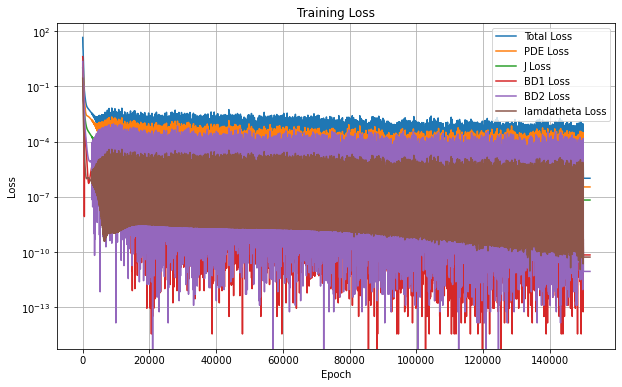

In [24]:
# 绘制损失曲线
plt.figure(figsize=(10, 6))
plt.plot(loss_history, label='Total Loss')
plt.plot(loss_PDE_history, label='PDE Loss')
plt.plot(loss_J_history, label='J Loss')
plt.plot(loss_BD1_history, label='BD1 Loss')
plt.plot(loss_BD2_history, label='BD2 Loss')
plt.plot(loss_lamdatheta_history, label='lamdatheta Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)
plt.savefig(r'E:\李辉\超弹性球柱PINN求解\论文修改\ES\ENGSTRUCT-D-26-05735-reviews\hyperelastic cylindrical shell_zhu_GeL_double_inverse problem\不同测量值对比\3个测量值\loss_curve.tiff')
plt.show()

In [25]:
R_test_bar = torch.linspace(A_bar, B_bar,50).view(-1, 1).requires_grad_(True)

# 计算网络输出
r_test_bar, P_r_test_bar = derivativs(R_test_bar, Net_r)

miu_test_bar,sigma_r_test_bar, sigma_theta_test_bar, sigma_z_test_bar, dsigma_r_r = derivativs2(R_test_bar,  Net_r)

beta=current_beta

lamdatheta_bar=r_test_bar/R_test_bar

r_test_pred_bar=r_test_bar.detach().numpy().reshape(-1,1)
lamdatheta_pred_bar=lamdatheta_bar.detach().numpy().reshape(-1,1)
miu_test_pred_bar= miu_test_bar.detach().numpy().reshape(-1,1)
sigma_r_test_pred_bar = sigma_r_test_bar.detach().numpy().reshape(-1,1)
sigma_theta_test_pred_bar = sigma_theta_test_bar.detach().numpy().reshape(-1,1)
sigma_z_test_pred_bar = sigma_z_test_bar.detach().numpy().reshape(-1,1)

In [26]:
miu_true = miu0_bar*(1+(miuB_bar/miuA_bar-1)*(R_test_bar**true_beta-A_bar**true_beta)/(B_bar**true_beta-A_bar**true_beta))

In [27]:
R_test_np_bar = R_test_bar.detach().numpy()

# 创建一个字典来存储所有数据
data_dict5 = {
    'R_train_bar': R_test_np_bar.flatten(),
    'r_test_pred_bar': r_test_pred_bar.flatten(),
    'lamdatheta_pred_bar': lamdatheta_pred_bar.flatten(),
    'sigma_r_test_pred_bar': sigma_r_test_pred_bar.flatten(),
    'sigma_theta_test_pred_bar': sigma_theta_test_pred_bar.flatten(),
    'sigma_z_test_pred_bar': sigma_z_test_pred_bar.flatten()
}

# 将字典转换为 DataFrame
df5 = pd.DataFrame(data_dict5)

# 保存为 CSV 文件
output_path = r'E:\李辉\超弹性球柱PINN求解\论文修改\ES\ENGSTRUCT-D-26-05735-reviews\hyperelastic cylindrical shell_zhu_GeL_double_inverse problem\不同测量值对比\3个测量值\PINN_predictions.csv'
df5.to_csv(output_path, index=False, encoding='utf-8')


print(f'预测值已保存')


预测值已保存


In [28]:

data_dict5 = {
    'epoch': epochs_list,   
    'beta':beta_list
    }
# 将字典转换为 DataFrame
df5 = pd.DataFrame(data_dict5)

# 保存为 CSV 文件  
output_path = r'E:\李辉\超弹性球柱PINN求解\论文修改\ES\ENGSTRUCT-D-26-05735-reviews\hyperelastic cylindrical shell_zhu_GeL_double_inverse problem\不同测量值对比\3个测量值\PINN_beta_predictions.csv'
df5.to_csv(output_path, index=False, encoding='utf-8')


print(f'预测值n已保存')

预测值n已保存


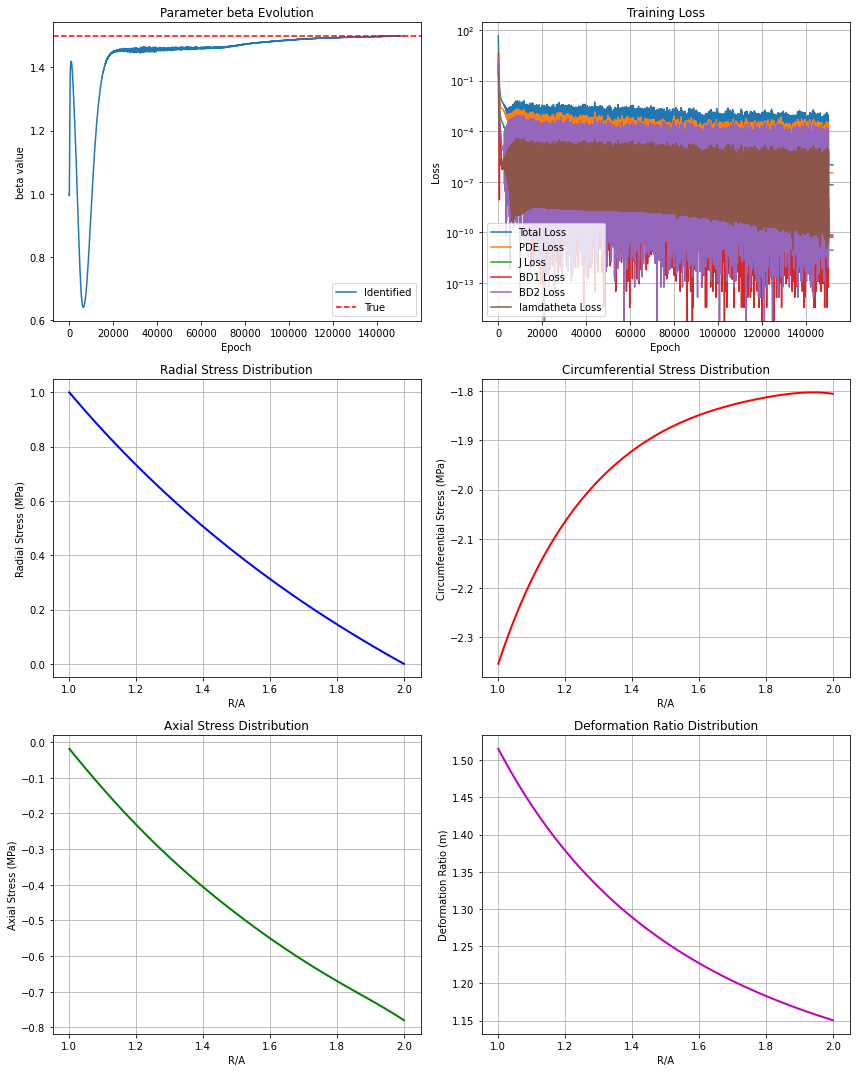


Final Results:
Final loss: 1.0169e-06


In [29]:
plt.figure(figsize=(12,15))

plt.subplot(3, 2, 1)
plt.plot(beta_history, label='Identified')
plt.axhline(y=true_beta, color='r', linestyle='--', label='True')
plt.xlabel('Epoch')
plt.ylabel('beta value')
plt.title('Parameter beta Evolution')
plt.legend()
plt.legend()

plt.subplot(3, 2, 2)
plt.plot(loss_history, label='Total Loss')
plt.plot(loss_PDE_history, label='PDE Loss')
plt.plot(loss_J_history, label='J Loss')
plt.plot(loss_BD1_history, label='BD1 Loss')
plt.plot(loss_BD2_history, label='BD2 Loss')
plt.plot(loss_lamdatheta_history, label='lamdatheta Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)


plt.subplot(3, 2, 3)
plt.plot(R_test_np_bar/A_bar, sigma_r_test_pred_bar*P/Pa, 'b-', linewidth=2)
plt.xlabel('R/A')
plt.ylabel('Radial Stress (MPa)')
plt.title('Radial Stress Distribution')
plt.grid(True)

plt.subplot(3, 2, 4)
plt.plot(R_test_np_bar/A_bar, sigma_theta_test_pred_bar*P/Pa, 'r-', linewidth=2)
plt.xlabel('R/A')
plt.ylabel('Circumferential Stress (MPa)')
plt.title('Circumferential Stress Distribution')
plt.grid(True)

plt.subplot(3, 2, 5)
plt.plot(R_test_np_bar/A_bar, sigma_z_test_pred_bar*P/Pa, 'g-', linewidth=2)
plt.xlabel('R/A')
plt.ylabel('Axial Stress (MPa)')
plt.title('Axial Stress Distribution')
plt.grid(True)

plt.subplot(3, 2, 6)
plt.plot(R_test_np_bar/A_bar,lamdatheta_pred_bar, 'm-', linewidth=2)
plt.xlabel('R/A')
plt.ylabel('Deformation Ratio (m)')
plt.title('Deformation Ratio Distribution')
plt.grid(True)

plt.tight_layout()
plt.savefig(r'E:\李辉\超弹性球柱PINN求解\论文修改\ES\ENGSTRUCT-D-26-05735-reviews\hyperelastic cylindrical shell_zhu_GeL_double_inverse problem\不同测量值对比\3个测量值\stress_deformation_curves.tiff', dpi=600, format='tiff', bbox_inches='tight')
plt.show()

# 打印最终结果
print("\nFinal Results:")
print(f"Final loss: {loss_history[-1]:.4e}")

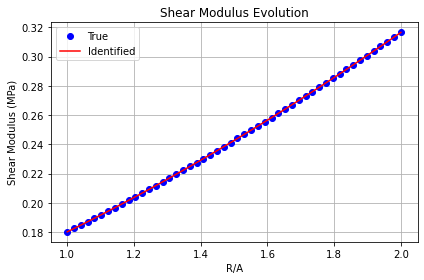

In [30]:
plt.plot(R_test_np_bar/A_bar, miu_true.detach().cpu().numpy()*miu0/1e6, 'bo', linewidth=2, label='True')
plt.plot(R_test_np_bar/A_bar, miu_test_pred_bar*miu0/1e6, 'r-', markersize=4, label='Identified')
plt.xlabel('R/A')
plt.ylabel('Shear Modulus (MPa)')
plt.title('Shear Modulus Evolution')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r'E:\李辉\超弹性球柱PINN求解\论文修改\ES\ENGSTRUCT-D-26-05735-reviews\hyperelastic cylindrical shell_zhu_GeL_double_inverse problem\不同测量值对比\3个测量值\Shear Modulus Evolution_curves.tiff', dpi=600, format='tiff', bbox_inches='tight')
plt.show()


In [31]:
print(f"Relative error: "f"{abs(best_beta - true_beta) / abs(true_beta) * 100:.2f}%")

Relative error: 0.07%


In [32]:
data = pd.read_csv('COMSOL_NH_GeL_double_zhu.csv')
R_bar = data.iloc[:, 0:1].to_numpy()
sigmar = data.iloc[:, 1:4].to_numpy()
sigmatheta = data.iloc[:, 4:7].to_numpy()
sigmaz = data.iloc[:, 7:10].to_numpy()
lamdatheta = data.iloc[:, 10:13].to_numpy()

In [33]:
# 获取COMSOL数据
COMSOL_R = R_bar.flatten()
COMSOL_sigma_r = sigmar[:,2:3]
COMSOL_sigma_theta = sigmatheta[:,2:3]
COMSOL_sigma_z = sigmaz[:, 2:3]
COMSOL_lamdatheta = lamdatheta[:,2:3]

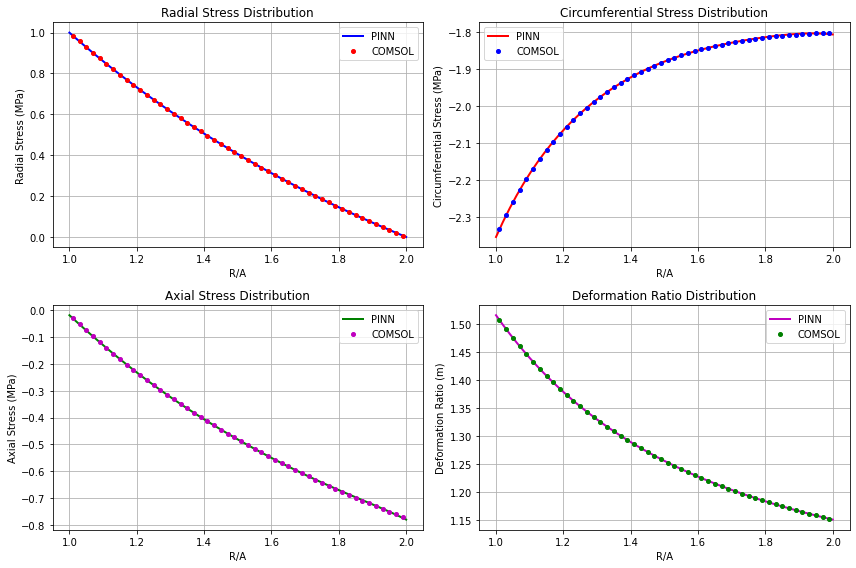


Final Results:
Final loss: 1.0169e-06


In [34]:
plt.figure(figsize=(12, 8))


plt.subplot(2, 2, 1)
plt.plot(R_test_np_bar/A_bar, sigma_r_test_pred_bar*P/Pa, 'b-', linewidth=2, label='PINN')
plt.plot(COMSOL_R, COMSOL_sigma_r, 'ro', markersize=4, label='COMSOL')
plt.xlabel('R/A')
plt.ylabel('Radial Stress (MPa)')
plt.title('Radial Stress Distribution')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(R_test_np_bar/A_bar, sigma_theta_test_pred_bar*P/Pa, 'r-', linewidth=2, label='PINN')
plt.plot(COMSOL_R, COMSOL_sigma_theta, 'bo', markersize=4, label='COMSOL')
plt.xlabel('R/A')
plt.ylabel('Circumferential Stress (MPa)')
plt.title('Circumferential Stress Distribution')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(R_test_np_bar/A_bar, sigma_z_test_pred_bar*P/Pa, 'g-', linewidth=2, label='PINN')
plt.plot(COMSOL_R, COMSOL_sigma_z, 'mo', markersize=4, label='COMSOL')
plt.xlabel('R/A')
plt.ylabel('Axial Stress (MPa)')
plt.title('Axial Stress Distribution')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(R_test_np_bar/A_bar, lamdatheta_pred_bar, 'm-', linewidth=2, label='PINN')
plt.plot(COMSOL_R, COMSOL_lamdatheta, 'go', markersize=4, label='COMSOL')
plt.xlabel('R/A')
plt.ylabel('Deformation Ratio (m)')
plt.title('Deformation Ratio Distribution')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(r'E:\李辉\超弹性球柱PINN求解\论文修改\ES\ENGSTRUCT-D-26-05735-reviews\hyperelastic cylindrical shell_zhu_GeL_double_inverse problem\不同测量值对比\3个测量值\stress_deformation_comparison.tiff', dpi=600, format='tiff', bbox_inches='tight')
plt.show()


# 打印最终结果
print("\nFinal Results:")
print(f"Final loss: {loss_history[-1]:.4e}")

In [35]:
# 创建极坐标网格
theta = np.linspace(0, 2 * np.pi, 100)
R = R_test_np_bar.flatten()  # 展平半径数组
Theta, R_grid = np.meshgrid(theta, R)
X = R_grid * np.cos(Theta)
Y = R_grid * np.sin(Theta)

# 将一维预测数据扩展为二维网格数据
sigma_r_2d = np.tile(sigma_r_test_pred_bar.flatten() * P / Pa, (len(theta), 1)).T
sigma_theta_2d = np.tile(sigma_theta_test_pred_bar.flatten() * P / Pa, (len(theta), 1)).T
sigma_z_2d = np.tile(sigma_z_test_pred_bar.flatten() * P / Pa, (len(theta), 1)).T
lamdatheta_2d = np.tile(lamdatheta_pred_bar.flatten(), (len(theta), 1)).T

In [36]:
data_dict = {
    'R': R_grid.flatten(),  # 半径网格
    'Theta': Theta.flatten(),  # 角度网格
    'X': X.flatten(),  # X坐标
    'Y': Y.flatten(),  # Y坐标
    'sigma_r_2d': sigma_r_2d.flatten(),  # σ_r 数据
    'sigma_theta_2d': sigma_theta_2d.flatten(),  # σ_θ 数据
    'sigma_z_2d': sigma_z_2d.flatten(),  # σ_z 数据
    'lamdatheta_2d': lamdatheta_2d.flatten()  # λθ 数据
}

# 将字典转换为 DataFrame
df = pd.DataFrame(data_dict)

# 保存为 CSV 文件
output_path = r'E:\李辉\超弹性球柱PINN求解\论文修改\ES\ENGSTRUCT-D-26-05735-reviews\hyperelastic cylindrical shell_zhu_GeL_double_inverse problem\不同测量值对比\3个测量值\PINN_2D_data.csv'
df.to_csv(output_path, index=False, encoding='utf-8')

print(f'极坐标数据已保存到 {output_path}')

极坐标数据已保存到 E:\李辉\超弹性球柱PINN求解\论文修改\ES\ENGSTRUCT-D-26-05735-reviews\hyperelastic cylindrical shell_zhu_GeL_double_inverse problem\不同测量值对比\3个测量值\PINN_2D_data.csv


In [37]:
# 创建极坐标网格
theta = np.linspace(0, 2 * np.pi, 100)
R_1 = COMSOL_R.flatten()  # 展平半径数组
Theta, R_grid1 = np.meshgrid(theta, R_1)
X = R_grid1 * np.cos(Theta)
Y = R_grid1 * np.sin(Theta)

# 将一维FDM数据扩展为二维网格数据
COMSOL_sigma_r_2d = np.tile(COMSOL_sigma_r.flatten(), (len(theta), 1)).T
COMSOL_sigma_theta_2d = np.tile(COMSOL_sigma_theta.flatten(), (len(theta), 1)).T
COMSOL_sigma_z_2d = np.tile(COMSOL_sigma_z.flatten() , (len(theta), 1)).T
COMSOL_lamdatheta_2d = np.tile(COMSOL_lamdatheta.flatten(), (len(theta), 1)).T


In [38]:
data_dict = {
    'R_1': R_grid1.flatten(),  # 半径网格
    'Theta': Theta.flatten(),  # 角度网格
    'X': X.flatten(),  # X坐标
    'Y': Y.flatten(),  # Y坐标
    'COMSOL_sigma_r_2d': COMSOL_sigma_r_2d.flatten(),  # σ_r 数据
    'COMSOL_sigma_theta_2d': COMSOL_sigma_theta_2d.flatten(),  # σ_θ 数据
    'COMSOL_sigma_z_2d': COMSOL_sigma_z_2d.flatten(),  # σ_z 数据
    'COMSOL_lamdatheta_2d': COMSOL_lamdatheta_2d.flatten()  # λθ 数据
}

# 将字典转换为 DataFrame
df = pd.DataFrame(data_dict)

# 保存为 CSV 文件
output_path = r'E:\李辉\超弹性球柱PINN求解\论文修改\ES\ENGSTRUCT-D-26-05735-reviews\hyperelastic cylindrical shell_zhu_GeL_double_inverse problem\不同测量值对比\3个测量值\COMSOL_2D_data.csv'
df.to_csv(output_path, index=False, encoding='utf-8')

print(f'极坐标数据已保存到 {output_path}')

极坐标数据已保存到 E:\李辉\超弹性球柱PINN求解\论文修改\ES\ENGSTRUCT-D-26-05735-reviews\hyperelastic cylindrical shell_zhu_GeL_double_inverse problem\不同测量值对比\3个测量值\COMSOL_2D_data.csv


In [39]:
sigma_r_2d_error= abs(sigma_r_2d-COMSOL_sigma_r_2d)
sigma_theta_2d_error= abs(sigma_theta_2d-COMSOL_sigma_theta_2d)
sigma_z_2d_error=abs(sigma_z_2d-COMSOL_sigma_z_2d)
lamdatheta_2d_error=abs(lamdatheta_2d-COMSOL_lamdatheta_2d)

In [40]:
data_dict = {
    'R': R_grid.flatten(),  # 半径网格
    'Theta': Theta.flatten(),  # 角度网格
    'X': X.flatten(),  # X坐标
    'Y': Y.flatten(),  # Y坐标
    'sigma_r_2d': sigma_r_2d_error.flatten(),  # σ_r 数据
    'sigma_theta_2d': sigma_theta_2d_error.flatten(),  # σ_θ 数据
    'sigma_z_2d': sigma_z_2d_error.flatten(),  # σ_z 数据
    'lamdatheta_2d': lamdatheta_2d_error.flatten()  # λθ 数据
}

# 将字典转换为 DataFrame
df = pd.DataFrame(data_dict)

# 保存为 CSV 文件
output_path = r'E:\李辉\超弹性球柱PINN求解\论文修改\ES\ENGSTRUCT-D-26-05735-reviews\hyperelastic cylindrical shell_zhu_GeL_double_inverse problem\不同测量值对比\3个测量值\CY_2D_error.csv'
df.to_csv(output_path, index=False, encoding='utf-8')

print(f'极坐标数据已保存到 {output_path}')

极坐标数据已保存到 E:\李辉\超弹性球柱PINN求解\论文修改\ES\ENGSTRUCT-D-26-05735-reviews\hyperelastic cylindrical shell_zhu_GeL_double_inverse problem\不同测量值对比\3个测量值\CY_2D_error.csv


In [41]:
# 计算L2相对误差
def L2_relative_error(true_values, computed_values):
    numerator = np.sqrt(np.sum((true_values - computed_values) ** 2))  # 分子：计算误差的L2范数
    denominator = np.sqrt(np.sum(true_values ** 2))  # 分母：实际值的L2范数
    return numerator / denominator

In [42]:
# 计算各个误差
sigma_r_2d_L2_error = L2_relative_error(sigma_r_2d, COMSOL_sigma_r_2d)
sigma_theta_2d_L2_error = L2_relative_error(sigma_theta_2d, COMSOL_sigma_theta_2d)
sigma_z_2d_L2_error = L2_relative_error(sigma_z_2d, COMSOL_sigma_z_2d)
lamdatheta_2d_L2_error = L2_relative_error(lamdatheta_2d, COMSOL_lamdatheta_2d)

In [43]:
# 打印误差结果
print(f"Sigma_r 2D L2 Relative Error: {sigma_r_2d_L2_error}")
print(f"sigma_z 2D L2 Relative Error: {sigma_theta_2d_L2_error}")
print(f"Sigma_theta 2D L2 Relative Error: {sigma_z_2d_L2_error}")
print(f"lamdatheta_2d L2 Relative Error: {lamdatheta_2d_L2_error}")

Sigma_r 2D L2 Relative Error: 0.01202206638686856
sigma_z 2D L2 Relative Error: 0.0031625895513542356
Sigma_theta 2D L2 Relative Error: 0.010123882464665737
lamdatheta_2d L2 Relative Error: 0.0022576248324498935


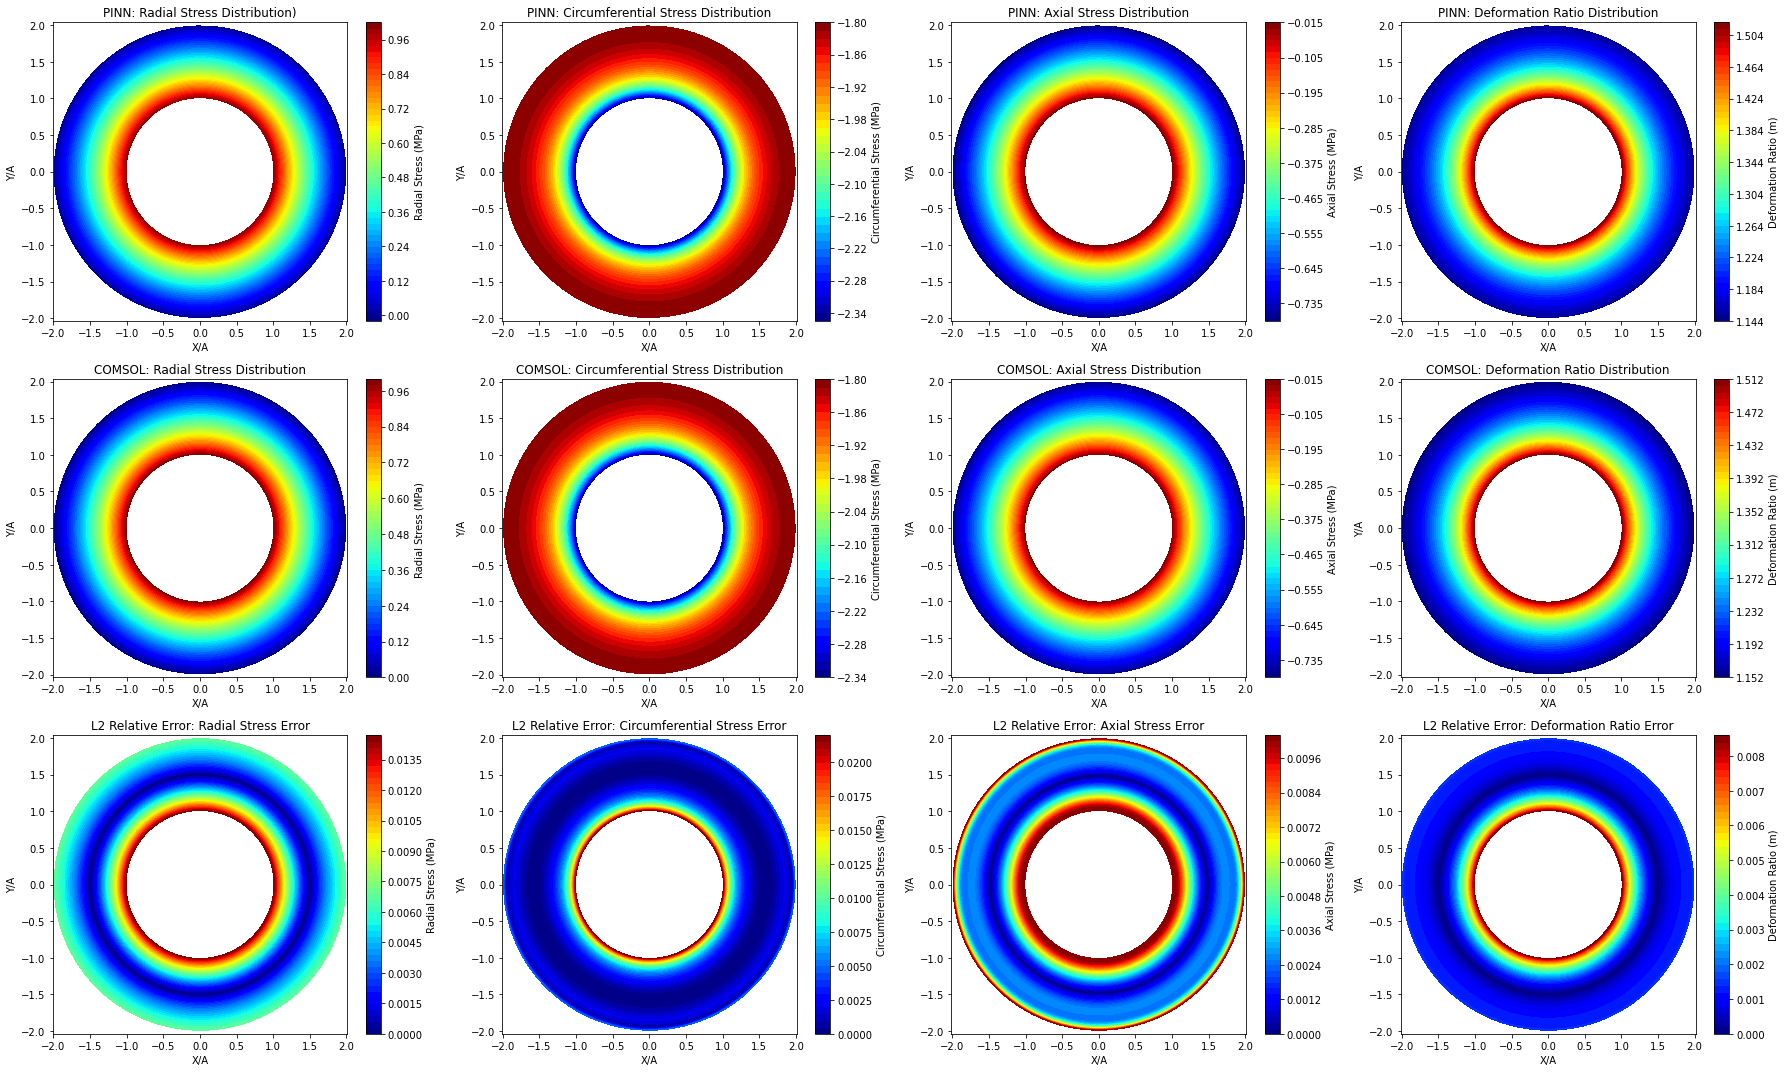

In [44]:
# 创建图形3x3排列
plt.figure(figsize=(25, 15))

# 第一排：PINN结果

# 第一列：PINN径向应力
plt.subplot(3, 4, 1)

contour1 = plt.contourf(X/A_bar, Y/A_bar, sigma_r_2d, 50, cmap='jet')
plt.colorbar(contour1,label='Radial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('PINN: Radial Stress Distribution)')
plt.axis('equal')

# 第二列：PINN环向应力
plt.subplot(3, 4, 2)

contour2 = plt.contourf(X/A_bar, Y/A_bar, sigma_theta_2d, 50, cmap='jet')
plt.colorbar(contour2, label='Circumferential Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('PINN: Circumferential Stress Distribution')
plt.axis('equal')

# 第三列：PINN轴向应力
plt.subplot(3, 4, 3)

contour3 = plt.contourf(X/A_bar, Y/A_bar, sigma_z_2d, 50, cmap='jet')

plt.colorbar(contour3, label='Axial Stress (MPa)')

plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('PINN: Axial Stress Distribution')
plt.axis('equal')


# 第四列：PINN伸长比
plt.subplot(3, 4, 4)
contour4 = plt.contourf(X/A_bar, Y/A_bar, lamdatheta_2d, 50, cmap='jet')
plt.colorbar(contour4, label='Deformation Ratio (m)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('PINN: Deformation Ratio Distribution')
plt.axis('equal')


# 第二排：FDM结果

# 第一列：FDM径向应力
plt.subplot(3, 4, 5)
contour5 = plt.contourf(X/A_bar, Y/A_bar, COMSOL_sigma_r_2d, 50, cmap='jet')
plt.colorbar(contour5, label='Radial Stress (MPa) ')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('COMSOL: Radial Stress Distribution')
plt.axis('equal')


# 第二列：COMSOL环向应力
plt.subplot(3, 4, 6)
contour6 = plt.contourf(X/A_bar, Y/A_bar, COMSOL_sigma_theta_2d, 50, cmap='jet')
plt.colorbar(contour6, label='Circumferential Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('COMSOL: Circumferential Stress Distribution')
plt.axis('equal')


# 第三列：COMSOL轴向应力
plt.subplot(3, 4, 7)
contour7 = plt.contourf(X/A_bar, Y/A_bar, COMSOL_sigma_z_2d, 50, cmap='jet')
plt.colorbar(contour7, label='Axial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('COMSOL: Axial Stress Distribution')
plt.axis('equal')


# 第四列：COMSOL伸长比
plt.subplot(3, 4, 8)
contour8 = plt.contourf(X/A_bar, Y/A_bar, COMSOL_lamdatheta_2d, 50, cmap='jet')
plt.colorbar(contour8, label='Deformation Ratio (m)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('COMSOL: Deformation Ratio Distribution')
plt.axis('equal')



# 第三排：误差

# 第一列：位移误差
plt.subplot(3, 4, 9)
contour9 = plt.contourf(X/A_bar, Y/A_bar, sigma_r_2d_error, 50, cmap='jet')
plt.colorbar(contour9, label='Radial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('L2 Relative Error: Radial Stress Error')
plt.axis('equal')

# 第二列：径向应力误差
plt.subplot(3, 4, 10)
contour10 = plt.contourf(X/A_bar, Y/A_bar,sigma_theta_2d_error, 50, cmap='jet')
plt.colorbar(contour10, label='Circumferential Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('L2 Relative Error: Circumferential Stress Error')
plt.axis('equal')



# 第三列：环向应力误差
plt.subplot(3, 4, 11)
contour11 = plt.contourf(X/A_bar, Y/A_bar,sigma_z_2d_error, 50, cmap='jet')
plt.colorbar(contour11, label='Axial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('L2 Relative Error: Axial Stress Error')
plt.axis('equal')



# 第四列：环向应力误差
plt.subplot(3, 4, 12)
contour12 = plt.contourf(X/A_bar, Y/A_bar, lamdatheta_2d_error, 50, cmap='jet')
plt.colorbar(contour12, label='Deformation Ratio (m)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('L2 Relative Error: Deformation Ratio Error')
plt.axis('equal')

# 调整布局以避免标签重叠
plt.tight_layout()

plt.savefig(r'E:\李辉\超弹性球柱PINN求解\论文修改\ES\ENGSTRUCT-D-26-05735-reviews\hyperelastic cylindrical shell_zhu_GeL_double_inverse problem\不同测量值对比\3个测量值\sanzu_2D_distribution.tiff', dpi=600, format='tiff', bbox_inches='tight')
plt.show()
